# Set up

## Change working directory

In [1]:
%cd ../

C:\Users\Skylar\Downloads\tools


## Install packages

In [2]:
# Placeholder

## Import development libraries

In [3]:
import hypothesis
import ipytest
import seaborn as sns
from hypothesis import strategies as st
from pandera import pandas as pa
from tools import typing as tstg

ipytest.autoconfig(rewrite_asserts=False)
sns.set()

## Import other libraries

In [4]:
import itertools
import pathlib
import typing

import numpy as np
import pandas as pd
import toolz as tz
import tqdm
from matplotlib import pyplot as plt
from tools import utils as tsus

## Declare constants

In [5]:
module: str = "data_analysis"

# Define describe_dataset

## Define

In [6]:
def describe_dataset(data: pd.DataFrame) -> pd.DataFrame:
    def get_most_frequent_values(data: pd.Series) -> dict:
        return data.value_counts(normalize=True).nlargest().round(decimals=3).to_dict()

    def describe(data: pd.DataFrame) -> pd.DataFrame:
        assign_args: dict[str, typing.Callable] = {
            "iqr": lambda x: x["75%"].sub(other=x["25%"]),
            "has_low_outlier": lambda x: x["iqr"].mul(other=1.5).rsub(other=x["25%"]).gt(other=x["min"]),
            "has_high_outlier": lambda x: x["iqr"].mul(other=1.5).add(other=x["75%"]).lt(other=x["max"]),
            "has_outlier": lambda x: x.filter(like="outlier").any(axis=1),
        }
        return data.describe().T.assign(**assign_args).drop(columns="count")

    objs: list[pd.DataFrame | pd.Series] = [
        data.dtypes.astype(dtype=str).rename(index="dtypes"),
        data.nunique().rename(index="nunique"),
        data.apply(func=get_most_frequent_values).rename(index="frequent_values"),
        data.isna().mean().rename(index="pct_missing"),
        data.isin(values=[-np.inf, np.inf]).mean().rename(index="pct_inf"),
        data.select_dtypes(include="number").lt(other=0).mean().rename(index="pct_negative"),
        data.eq(other=0).mean().rename(index="pct_zero"),
        data.pipe(func=describe),
    ]
    return pd.concat(objs=objs, axis=1).sort_values(by=["dtypes", "nunique"]).round(decimals=3)

## Demonstrate

In [7]:
titanic_data: pd.DataFrame = sns.load_dataset(name="titanic")
dataset_description: pd.DataFrame = describe_dataset(data=titanic_data)
dataset_description

,dtypes,nunique,frequent_values,pct_missing,pct_inf,pct_negative,pct_zero,mean,std,min,25%,50%,75%,max,iqr,has_low_outlier,has_high_outlier,has_outlier
adult_male,bool,2,"{True: 0.603, False: 0.397}",0.000,0.0,NaN,0.397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alone,bool,2,"{True: 0.603, False: 0.397}",0.000,0.0,NaN,0.397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,category,3,"{'Third': 0.551, 'First': 0.242, 'Second': 0.207}",0.000,0.0,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deck,category,7,"{'C': 0.291, 'B': 0.232, 'D': 0.163, 'E': 0.15...",0.772,0.0,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,float64,88,"{24.0: 0.042, 22.0: 0.038, 18.0: 0.036, 28.0: ...",0.199,0.0,0.0,0.000,29.699,14.526,0.42,20.125,28.000,38.0,80.000,17.875,False,True,True
fare,float64,248,"{8.05: 0.048, 13.0: 0.047, 7.8958: 0.043, 7.75...",0.000,0.0,0.0,0.017,32.204,49.693,0.00,7.910,14.454,31.0,512.329,23.090,False,True,True
survived,int64,2,"{0: 0.616, 1: 0.384}",0.000,0.0,0.0,0.616,0.384,0.487,0.00,0.000,0.000,1.0,1.000,1.000,False,False,False
pclass,int64,3,"{3: 0.551, 1: 0.242, 2: 0.207}",0.000,0.0,0.0,0.000,2.309,0.836,1.00,2.000,3.000,3.0,3.000,1.000,False,False,False
sibsp,int64,7,"{0: 0.682, 1: 0.235, 2: 0.031, 4: 0.02, 3: 0.018}",0.000,0.0,0.0,0.682,0.523,1.103,0.00,0.000,0.000,1.0,8.000,1.000,False,True,True
parch,int64,7,"{0: 0.761, 1: 0.132, 2: 0.09, 5: 0.006, 3: 0.006}",0.000,0.0,0.0,0.761,0.382,0.806,0.00,0.000,0.000,0.0,6.000,0.000,False,True,True


## Test

In [8]:
%%ipytest

def test_high_outlier() -> None:
    data = pd.DataFrame(data={'a': [1, 2, 3, 1e2]})
    out: pd.DataFrame = describe_dataset(data=data)
    assert out.loc['a', 'has_high_outlier'] == True

def test_low_outlier() -> None:
    data = pd.DataFrame(data={'a': [-1e2, 1, 2, 3]})
    out: pd.DataFrame = describe_dataset(data=data)
    assert out.loc['a', 'has_low_outlier'] == True

..                                                                                           [100%]
======================================== warnings summary =========================================
env\Lib\site-packages\_pytest\config\__init__.py:1309
  C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\_pytest\config\__init__.py:1309: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\Lib\site-packages\_pytest\config\__init__.py:1309
  C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\_pytest\config\__init__.py:1309: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\Lib\site-packages\_pytest\config\__init__.py:1309
  C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\_pytest\config\__init__.py:1309: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Define describe_datasets

## Define

In [9]:
def describe_datasets(
    reference_data: pd.DataFrame,
    current_data: pd.DataFrame,
    filter_to_common_columns: bool = True,
    filter_to_differences: bool = True,
) -> pd.DataFrame:
    common_columns: pd.Index = reference_data.columns.intersection(other=current_data.columns)
    objs: list[pd.Series] = tz.pipe(
        [reference_data, current_data],
        tz.curried.map(lambda x: x.loc[:, common_columns] if filter_to_common_columns else x),
        tz.curried.map(lambda x: describe_dataset(data=x).select_dtypes(include="number").stack()),
        list,
    )
    assign_args: dict[str, typing.Callable] = {"difference": lambda x: x.diff(axis=1).iloc[:, -1]}
    description: pd.DataFrame = pd.concat(objs=objs, axis=1, keys=["reference", "current"]).assign(**assign_args)
    if filter_to_differences:
        eps: float = np.finfo(dtype=float).eps
        return description.loc[lambda x: x["difference"].abs().gt(other=eps), :]
    return description

## Demonstrate

In [10]:
titanic_train_data: pd.DataFrame = titanic_data.sample(frac=8e-1)
titanic_test_data: pd.DataFrame = titanic_data.drop(index=titanic_train_data.index)
datasets_description: pd.DataFrame = describe_datasets(
    reference_data=titanic_train_data, current_data=titanic_test_data
)
datasets_description

reference  current  difference
adult_male  pct_zero         0.396    0.404       0.008
alone       pct_zero         0.400    0.388      -0.012
deck        pct_missing      0.770    0.781       0.011
age         nunique         86.000   54.000     -32.000
            pct_missing      0.196    0.208       0.012
            mean            29.960   28.639      -1.321
            std             14.814   13.292      -1.522
            min              0.420    0.670       0.250
            25%             20.000   21.000       1.000
            75%             39.000   35.000      -4.000
            max             80.000   64.000     -16.000
            iqr             19.000   14.000      -5.000
fare        nunique        225.000   99.000    -126.000
            pct_zero         0.018    0.011      -0.007
            mean            33.004   29.001      -4.003
            std             51.425   42.026      -9.399
            25%              7.925    7.896      -0.029
            50%             14.500   13.000      -1.500
            75%             31.388   27.721      -3.667
            max            512.329  262.375    -249.954
            iqr             23.462   19.825      -3.637
survived    pct_zero         0.609    0.646       0.037
            mean             0.391    0.354      -0.037
            std              0.488    0.480      -0.008
pclass      mean             2.283    2.410       0.127
            std              0.840    0.813      -0.027
            25%              1.000    2.000       1.000
            iqr              2.000    1.000      -1.000
sibsp       pct_zero         0.673    0.719       0.046
            mean             0.541    0.449      -0.092
            std              1.120    1.031      -0.089
parch       nunique          7.000    4.000      -3.000
            pct_zero         0.763    0.753      -0.010
            mean             0.384    0.371      -0.013
            std              0.811    0.787      -0.024
            max              6.000    5.000      -1.000
embarked    pct_missing      0.003    0.000      -0.003
embark_town pct_missing      0.003    0.000      -0.003

## Test

In [11]:
%%ipytest

def test_common_columns() -> None:
    ref = pd.DataFrame(data={'a': range(1, 4), 'b': range(4, 7)})
    cur = pd.DataFrame(data={'a': range(1, 4), 'c': range(4, 7)})
    shared_args = dict(reference_data=ref, current_data=cur, filter_to_differences=False)
    out: pd.DataFrame = describe_datasets(filter_to_common_columns=True, **shared_args)
    assert 'a' in out.index.get_level_values(level=0)
    assert 'b' not in out.index.get_level_values(level=0)
    out: pd.DataFrame = describe_datasets(filter_to_common_columns=False, **shared_args)
    assert 'b' in out.index.get_level_values(level=0)

def test_zero_differences() -> None:
    ref = pd.DataFrame(data={'a': range(1, 4)})
    cur = pd.DataFrame(data={'a': range(1, 4)})
    shared_args = dict(reference_data=ref, current_data=cur, filter_to_common_columns=True)
    out: pd.DataFrame = describe_datasets(filter_to_differences=True, **shared_args)
    assert out.empty
    out: pd.DataFrame = describe_datasets(filter_to_differences=False, **shared_args)
    assert not out.empty
    assert out['difference'].eq(other=0).all()

..                                                                                           [100%]
======================================== warnings summary =========================================
env\Lib\site-packages\_pytest\config\__init__.py:1309
  C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\_pytest\config\__init__.py:1309: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\Lib\site-packages\_pytest\config\__init__.py:1309
  C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\_pytest\config\__init__.py:1309: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\Lib\site-packages\_pytest\config\__init__.py:1309
  C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\_pytest\config\__init__.py:1309: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Define get_correlations

## Define

In [12]:
def get_correlations(
    X: pd.DataFrame, y: pd.Series | None = None, is_memory_low: bool = False, method: str = "spearman"
) -> pd.Series:
    def process(data: pd.Series, method: str = method) -> pd.Series:
        return data.rename(index=method).dropna().sort_values()

    X_numeric: pd.DataFrame = X.select_dtypes(include="number")
    if y is None:
        if is_memory_low:
            column_pairs: list[tuple[str, str]] = list(itertools.combinations(iterable=X_numeric.columns, r=2))
            correlations: dict[tuple[str, str], float] = {}
            for column_pair in tqdm.tqdm(iterable=column_pairs):  # type: tuple[str, str]
                correlations[column_pair] = X_numeric[list(column_pair)].corr(method=method).iloc[0, 1]
            return pd.Series(data=correlations).pipe(func=process)
        else:
            fn: typing.Callable = tz.compose_left(tz.partial(np.ones_like, dtype=bool), tz.partial(np.triu, k=1))
            return X_numeric.corr(method=method).where(cond=fn).stack().pipe(func=process)
    return X_numeric.corrwith(other=y, method=method).pipe(func=process)

## Demonstrate

In [13]:
target: str = "survived"
X_train: pd.DataFrame = titanic_train_data.drop(columns=target)
y_train: pd.Series = titanic_train_data[target]
correlations_between_features: pd.Series = get_correlations(X=X_train)
correlations_with_target: pd.Series = get_correlations(X=X_train, y=y_train)
correlations_between_features, correlations_with_target

(pclass  fare    -0.692089
         age     -0.385672
 age     parch   -0.254396
         sibsp   -0.168542
 pclass  sibsp   -0.067778
         parch   -0.006049
 age     fare     0.151995
 parch   fare     0.392971
 sibsp   parch    0.470570
         fare     0.471819
 Name: spearman, dtype: float64,
 pclass   -0.361499
 age      -0.026742
 sibsp     0.089146
 parch     0.138116
 fare      0.344614
 Name: spearman, dtype: float64)

## Test

In [14]:
%%ipytest

def test_perfect_correlation() -> None:
    X = pd.DataFrame(data={'a': range(1, 4), 'b': range(1, 4)})
    out: pd.Series = get_correlations(X=X)
    assert out.loc['a'].loc['b'] == 1e0

def test_equivalent_handling_of_constant_columns() -> None:
    X = pd.DataFrame(data={"a": 1, "b": range(3), "c": range(1, 4)})
    pd.testing.assert_series_equal(
        left=get_correlations(X=X, is_memory_low=False), right=get_correlations(X=X, is_memory_low=True)
    )

def test_nonnumeric_columns() -> None:
    X = pd.DataFrame(data={'a': range(1, 4), 'b': list('abc')})
    out: pd.Series = get_correlations(X=X)
    assert out.empty

def test_perfect_correlations_with_target() -> None:
    X = pd.DataFrame(data={'a': range(1, 4), 'b': range(3, 0, -1)})
    y = pd.Series(data=range(1, 4))
    out: pd.Series = get_correlations(X=X, y=y)
    assert out['a'] == 1e0
    assert out['b'] == -1e0

....                                                                                         [100%]
======================================== warnings summary =========================================
env\Lib\site-packages\_pytest\config\__init__.py:1309
  C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\_pytest\config\__init__.py:1309: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\Lib\site-packages\_pytest\config\__init__.py:1309
  C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\_pytest\config\__init__.py:1309: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\Lib\site-packages\_pytest\config\__init__.py:1309
  C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\_pytest\config\__init__.py:1309: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Define get_differences

## Define

In [15]:
def get_differences(data: pd.DataFrame, first_column: str, second_column: str) -> pd.DataFrame:
    columns: list[str] = [first_column, second_column]
    assign_args: dict[str, typing.Callable] = {
        "abs_diff": lambda x: x.loc[:, columns].diff(axis=1).iloc[:, -1].abs(),
        "mean": lambda x: x.loc[:, columns].mean(axis=1),
        "pct_diff": lambda x: x["abs_diff"].div(other=x["mean"].where(cond=x["mean"].ne(other=0))),
    }
    return data.assign(**assign_args)

## Demonstrate

In [16]:
datasets_differences: pd.DataFrame = get_differences(
    data=datasets_description, first_column="reference", second_column="current"
)
datasets_differences

reference  current  difference  abs_diff      mean  \
adult_male  pct_zero         0.396    0.404       0.008     0.008    0.4000   
alone       pct_zero         0.400    0.388      -0.012     0.012    0.3940   
deck        pct_missing      0.770    0.781       0.011     0.011    0.7755   
age         nunique         86.000   54.000     -32.000    32.000   70.0000   
            pct_missing      0.196    0.208       0.012     0.012    0.2020   
            mean            29.960   28.639      -1.321     1.321   29.2995   
            std             14.814   13.292      -1.522     1.522   14.0530   
            min              0.420    0.670       0.250     0.250    0.5450   
            25%             20.000   21.000       1.000     1.000   20.5000   
            75%             39.000   35.000      -4.000     4.000   37.0000   
            max             80.000   64.000     -16.000    16.000   72.0000   
            iqr             19.000   14.000      -5.000     5.000   16.5000   
fare        nunique        225.000   99.000    -126.000   126.000  162.0000   
            pct_zero         0.018    0.011      -0.007     0.007    0.0145   
            mean            33.004   29.001      -4.003     4.003   31.0025   
            std             51.425   42.026      -9.399     9.399   46.7255   
            25%              7.925    7.896      -0.029     0.029    7.9105   
            50%             14.500   13.000      -1.500     1.500   13.7500   
            75%             31.388   27.721      -3.667     3.667   29.5545   
            max            512.329  262.375    -249.954   249.954  387.3520   
            iqr             23.462   19.825      -3.637     3.637   21.6435   
survived    pct_zero         0.609    0.646       0.037     0.037    0.6275   
            mean             0.391    0.354      -0.037     0.037    0.3725   
            std              0.488    0.480      -0.008     0.008    0.4840   
pclass      mean             2.283    2.410       0.127     0.127    2.3465   
            std              0.840    0.813      -0.027     0.027    0.8265   
            25%              1.000    2.000       1.000     1.000    1.5000   
            iqr              2.000    1.000      -1.000     1.000    1.5000   
sibsp       pct_zero         0.673    0.719       0.046     0.046    0.6960   
            mean             0.541    0.449      -0.092     0.092    0.4950   
            std              1.120    1.031      -0.089     0.089    1.0755   
parch       nunique          7.000    4.000      -3.000     3.000    5.5000   
            pct_zero         0.763    0.753      -0.010     0.010    0.7580   
            mean             0.384    0.371      -0.013     0.013    0.3775   
            std              0.811    0.787      -0.024     0.024    0.7990   
            max              6.000    5.000      -1.000     1.000    5.5000   
embarked    pct_missing      0.003    0.000      -0.003     0.003    0.0015   
embark_town pct_missing      0.003    0.000      -0.003     0.003    0.0015   

                         pct_diff  
adult_male  pct_zero     0.020000  
alone       pct_zero     0.030457  
deck        pct_missing  0.014184  
age         nunique      0.457143  
            pct_missing  0.059406  
            mean         0.045086  
            std          0.108304  
            min          0.458716  
            25%          0.048780  
            75%          0.108108  
            max          0.222222  
            iqr          0.303030  
fare        nunique      0.777778  
            pct_zero     0.482759  
            mean         0.129119  
            std          0.201154  
            25%          0.003666  
            50%          0.109091  
            75%          0.124076  
            max          0.645289  
            iqr          0.168041  
survived    pct_zero     0.058964  
            mean         0.099329  
            std          0.016529  
pclass      mean         0.054123  
       

## Test

In [17]:
%%ipytest

# Helper(s)
columns: dict[str, pa.Column] = {
    "a": pa.Column(dtype=float, nullable=True),
    "b": pa.Column(dtype=float, nullable=True)
}
data_strategy: st.SearchStrategy[pd.DataFrame] = pa.DataFrameSchema(columns=columns).strategy(size=5)

# Deterministic test(s)
def test_division_by_zero() -> None:
    data = pd.DataFrame(data={'a': [0] * 3, 'b': [0] * 3})
    out: pd.DataFrame = get_differences(data=data, first_column='a', second_column='b')
    assert out['pct_diff'].isna().all()

def test_na_propagation() -> None:
    data = pd.DataFrame(data={'a': [0, np.nan, 2], 'b': [1, 2, np.nan]})
    out: pd.DataFrame = get_differences(data=data, first_column='a', second_column='b')
    assert out['pct_diff'].iloc[1:].isna().all()

# Property-based test(s)
@hypothesis.given(data=data_strategy)
def test_symmetric_percent_difference(data: pd.DataFrame) -> None:
    first_differences: pd.DataFrame = get_differences(data=data, first_column='a', second_column='b')
    second_differences: pd.DataFrame = get_differences(data=data, first_column='b', second_column='a')
    pd.testing.assert_series_equal(left=first_differences['pct_diff'], right=second_differences['pct_diff'])

...                                                                                          [100%]
======================================== warnings summary =========================================
env\Lib\site-packages\_pytest\config\__init__.py:1309
  C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\_pytest\config\__init__.py:1309: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\Lib\site-packages\_pytest\config\__init__.py:1309
  C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\_pytest\config\__init__.py:1309: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\Lib\site-packages\_pytest\config\__init__.py:1309
  C:\Users\Skylar\Downloads\tools\env\Lib\site-packages\_pytest\config\__init__.py:1309: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Define plot_histogram

## Define

In [18]:
def plot_histogram(data: pd.Series, bbox: list | tuple = (1.2, 0, 2e-1, 1), **kwargs) -> plt.Axes:
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
    ax: plt.Axes = data.plot(kind="hist", **filtered_kwargs)
    pd.plotting.table(ax=ax, data=data.describe().round(decimals=3), bbox=bbox)
    return ax

## Demonstrate

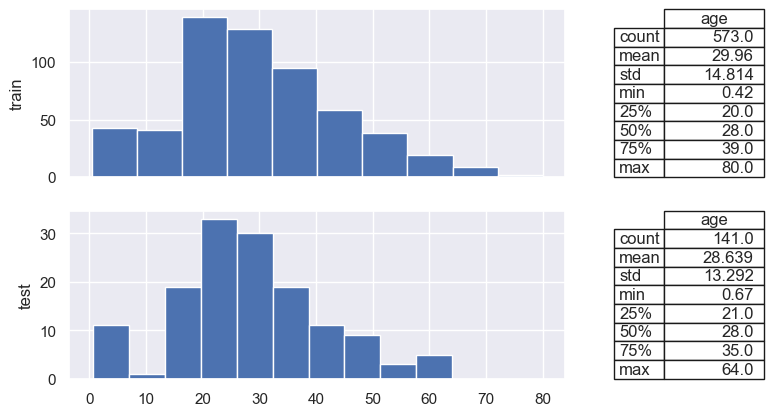

In [19]:
fig, axes = plt.subplots(nrows=2, sharex=True)  # type: tstg.FigAxes
for split, ax in zip(["train", "test"], axes.flat):  # type: tuple[str, plt.Axes]
    plot_histogram(data=eval("titanic_%s_data" % split)["age"], ax=ax)
    ax.set(ylabel=split)

## Test

In [20]:
# Placeholder

# Define plot_largest_barh

## Define

In [21]:
def plot_largest_barh(
    data: pd.Series, n: int = int(1e1), return_signed: bool = True, bbox: list | tuple = (1.2, 0, 2e-1, 1), **kwargs
) -> plt.Axes:
    largest_unsigned_data: pd.Series = data.abs().nlargest(n=n).iloc[::-1]
    largest_signed_data: pd.Series = data.loc[largest_unsigned_data.index].sort_values()
    plot_data: pd.Series = largest_signed_data if return_signed else largest_unsigned_data
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
    ax: plt.Axes = plot_data.plot(kind="barh", **filtered_kwargs)
    formatted_data: pd.Series = plot_data.reset_index(drop=True).round(decimals=3).iloc[::-1]
    pd.plotting.table(ax=ax, data=formatted_data, bbox=bbox)
    return ax

## Demonstrate

<Axes: >

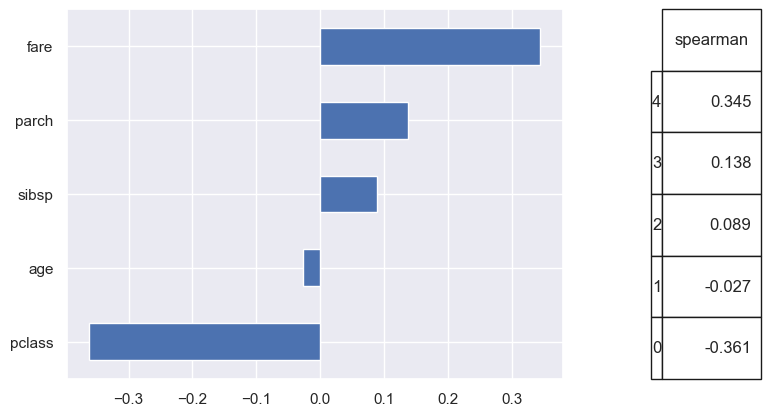

In [22]:
plot_largest_barh(data=correlations_with_target)

## Test

In [23]:
# Placeholder

# Define plot_value_counts

## Define

In [24]:
def plot_value_counts(data: pd.Series, n: int = int(1e1), bbox: list | tuple | None = None, **kwargs) -> plt.Axes:
    plot_data: pd.DataFrame = (
        data.value_counts(dropna=False)
        .to_frame(name="cnt")
        .assign(**{"pct": lambda x: x["cnt"].pipe(func=lambda y: y.div(other=y.sum()))})
        .nlargest(n=n, columns="cnt")
    )
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
    ax: plt.Axes = plot_data["cnt"].iloc[::-1].plot(kind="barh", **filtered_kwargs)
    if bbox is None:
        bbox = (1.2, 0, 4e-1, 2e-1 * plot_data.shape[0])
    pd.plotting.table(ax=ax, data=plot_data.round(decimals=3), bbox=bbox)
    return ax

## Demonstrate

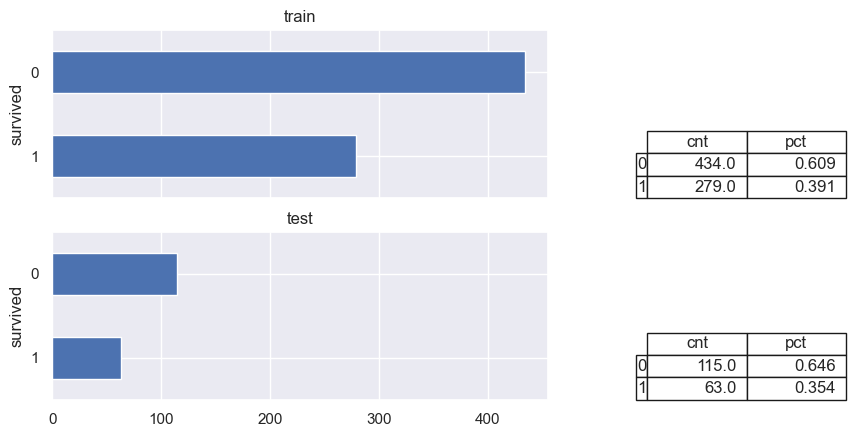

In [25]:
fig, axes = plt.subplots(nrows=2, sharex=True)  # type: tstg.FigAxes
for split, ax in zip(["train", "test"], axes.flat):  # type: tuple[str, plt.Axes]
    plot_value_counts(data=eval("titanic_%s_data" % split)[target], ax=ax)
    ax.set(title=split)

## Test

In [26]:
# Placeholder

# Define plot_dataset_description

## Define

In [27]:
def plot_dataset_description(
    dataset_description: pd.DataFrame,
    outputs_directory: pathlib.Path | None,
    is_in_notebook: bool,
    other_columns: list | None = None,
) -> None:
    # Plot dtypes
    column: str = "dtypes"
    dataset_description[column].pipe(func=plot_value_counts)
    shared_args = dict(outputs_directory=outputs_directory, is_in_notebook=is_in_notebook)
    tsus.save_show_and_close(filename=column, **shared_args)
    # Plot other columns
    columns: list = other_columns or ["nunique", "pct_inf", "pct_missing", "pct_negative", "pct_zero", "min", "max"]
    for column in columns:  # type: str
        dataset_description[column].pipe(func=pd.to_numeric, errors="coerce").dropna().pipe(func=plot_histogram)
        tsus.save_show_and_close(filename=column, **shared_args)

## Demonstrate

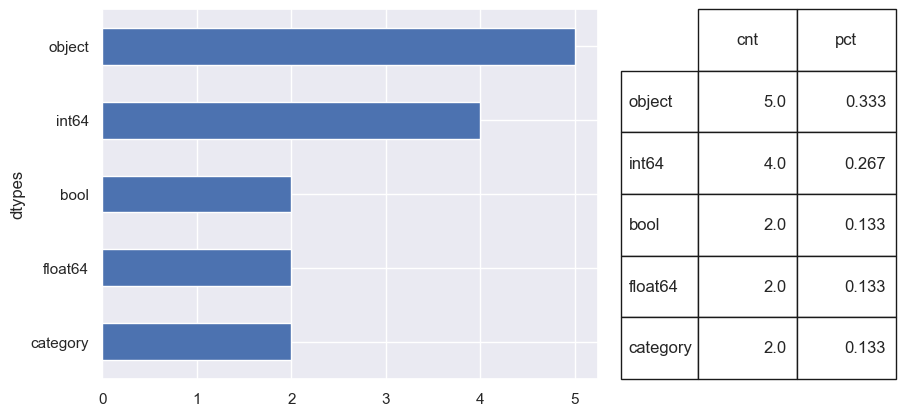

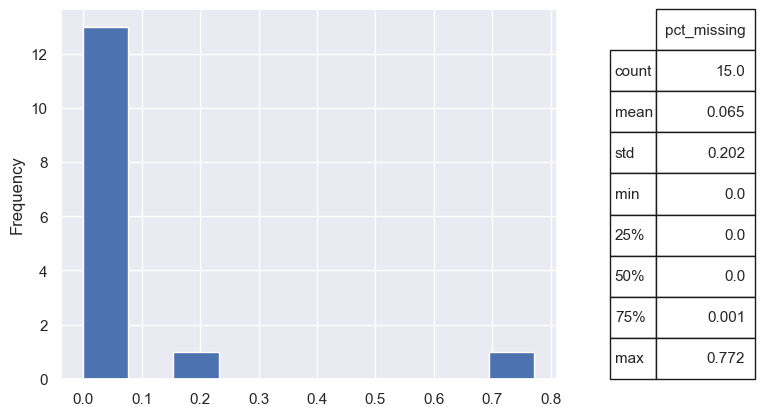

In [28]:
plot_dataset_description(
    dataset_description=dataset_description, outputs_directory=None, is_in_notebook=True, other_columns=["pct_missing"]
)

## Test

In [29]:
# Placeholder

# Write module

## Write

In [30]:
module_path: str = "src/tools/%s.py" % module

In [31]:
%%file $module_path

import itertools
import pathlib
import typing

import numpy as np
import pandas as pd
import toolz as tz
import tqdm
from matplotlib import pyplot as plt
from tools import utils as tsus

def describe_dataset(data: pd.DataFrame) -> pd.DataFrame:
    def get_most_frequent_values(data: pd.Series) -> dict:
        return data.value_counts(normalize=True).nlargest().round(decimals=3).to_dict()

    def describe(data: pd.DataFrame) -> pd.DataFrame:
        assign_args: dict[str, typing.Callable] = {
            "iqr": lambda x: x["75%"].sub(other=x["25%"]),
            "has_low_outlier": lambda x: x["iqr"].mul(other=1.5).rsub(other=x["25%"]).gt(other=x["min"]),
            "has_high_outlier": lambda x: x["iqr"].mul(other=1.5).add(other=x["75%"]).lt(other=x["max"]),
            "has_outlier": lambda x: x.filter(like="outlier").any(axis=1),
        }
        return data.describe().T.assign(**assign_args).drop(columns="count")

    objs: list[pd.DataFrame | pd.Series] = [
        data.dtypes.astype(dtype=str).rename(index="dtypes"),
        data.nunique().rename(index="nunique"),
        data.apply(func=get_most_frequent_values).rename(index="frequent_values"),
        data.isna().mean().rename(index="pct_missing"),
        data.isin(values=[-np.inf, np.inf]).mean().rename(index="pct_inf"),
        data.select_dtypes(include="number").lt(other=0).mean().rename(index="pct_negative"),
        data.eq(other=0).mean().rename(index="pct_zero"),
        data.pipe(func=describe),
    ]
    return pd.concat(objs=objs, axis=1).sort_values(by=["dtypes", "nunique"]).round(decimals=3)

def describe_datasets(
    reference_data: pd.DataFrame,
    current_data: pd.DataFrame,
    filter_to_common_columns: bool = True,
    filter_to_differences: bool = True,
) -> pd.DataFrame:
    common_columns: pd.Index = reference_data.columns.intersection(other=current_data.columns)
    objs: list[pd.Series] = tz.pipe(
        [reference_data, current_data],
        tz.curried.map(lambda x: x.loc[:, common_columns] if filter_to_common_columns else x),
        tz.curried.map(lambda x: describe_dataset(data=x).select_dtypes(include="number").stack()),
        list,
    )
    assign_args: dict[str, typing.Callable] = {"difference": lambda x: x.diff(axis=1).iloc[:, -1]}
    description: pd.DataFrame = pd.concat(objs=objs, axis=1, keys=["reference", "current"]).assign(**assign_args)
    if filter_to_differences:
        eps: float = np.finfo(dtype=float).eps
        return description.loc[lambda x: x["difference"].abs().gt(other=eps), :]
    return description

def get_correlations(
    X: pd.DataFrame, y: pd.Series | None = None, is_memory_low: bool = False, method: str = "spearman"
) -> pd.Series:
    def process(data: pd.Series, method: str = method) -> pd.Series:
        return data.rename(index=method).dropna().sort_values()

    X_numeric: pd.DataFrame = X.select_dtypes(include="number")
    if y is None:
        if is_memory_low:
            column_pairs: list[tuple[str, str]] = list(itertools.combinations(iterable=X_numeric.columns, r=2))
            correlations: dict[tuple[str, str], float] = {}
            for column_pair in tqdm.tqdm(iterable=column_pairs):  # type: tuple[str, str]
                correlations[column_pair] = X_numeric[list(column_pair)].corr(method=method).iloc[0, 1]
            return pd.Series(data=correlations).pipe(func=process)
        else:
            fn: typing.Callable = tz.compose_left(tz.partial(np.ones_like, dtype=bool), tz.partial(np.triu, k=1))
            return X_numeric.corr(method=method).where(cond=fn).stack().pipe(func=process)
    return X_numeric.corrwith(other=y, method=method).pipe(func=process)

def get_differences(data: pd.DataFrame, first_column: str, second_column: str) -> pd.DataFrame:
    columns: list[str] = [first_column, second_column]
    assign_args: dict[str, typing.Callable] = {
        "abs_diff": lambda x: x.loc[:, columns].diff(axis=1).iloc[:, -1].abs(),
        "mean": lambda x: x.loc[:, columns].mean(axis=1),
        "pct_diff": lambda x: x["abs_diff"].div(other=x["mean"].where(cond=x["mean"].ne(other=0))),
    }
    return data.assign(**assign_args)

def plot_dataset_description(
    dataset_description: pd.DataFrame,
    outputs_directory: pathlib.Path | None,
    is_in_notebook: bool,
    other_columns: list | None = None,
) -> None:
    # Plot dtypes
    column: str = "dtypes"
    dataset_description[column].pipe(func=plot_value_counts)
    shared_args = dict(outputs_directory=outputs_directory, is_in_notebook=is_in_notebook)
    tsus.save_show_and_close(filename=column, **shared_args)
    # Plot other columns
    columns: list = other_columns or ["nunique", "pct_inf", "pct_missing", "pct_negative", "pct_zero", "min", "max"]
    for column in columns:  # type: str
        dataset_description[column].pipe(func=pd.to_numeric, errors="coerce").dropna().pipe(func=plot_histogram)
        tsus.save_show_and_close(filename=column, **shared_args)

def plot_histogram(data: pd.Series, bbox: list | tuple = (1.2, 0, 2e-1, 1), **kwargs) -> plt.Axes:
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
    ax: plt.Axes = data.plot(kind="hist", **filtered_kwargs)
    pd.plotting.table(ax=ax, data=data.describe().round(decimals=3), bbox=bbox)
    return ax

def plot_largest_barh(
    data: pd.Series, n: int = int(1e1), return_signed: bool = True, bbox: list | tuple = (1.2, 0, 2e-1, 1), **kwargs
) -> plt.Axes:
    largest_unsigned_data: pd.Series = data.abs().nlargest(n=n).iloc[::-1]
    largest_signed_data: pd.Series = data.loc[largest_unsigned_data.index].sort_values()
    plot_data: pd.Series = largest_signed_data if return_signed else largest_unsigned_data
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
    ax: plt.Axes = plot_data.plot(kind="barh", **filtered_kwargs)
    formatted_data: pd.Series = plot_data.reset_index(drop=True).round(decimals=3).iloc[::-1]
    pd.plotting.table(ax=ax, data=formatted_data, bbox=bbox)
    return ax

def plot_value_counts(data: pd.Series, n: int = int(1e1), bbox: list | tuple | None = None, **kwargs) -> plt.Axes:
    plot_data: pd.DataFrame = (
        data.value_counts(dropna=False)
        .to_frame(name="cnt")
        .assign(**{"pct": lambda x: x["cnt"].pipe(func=lambda y: y.div(other=y.sum()))})
        .nlargest(n=n, columns="cnt")
    )
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in ["kind"], d=kwargs)
    ax: plt.Axes = plot_data["cnt"].iloc[::-1].plot(kind="barh", **filtered_kwargs)
    if bbox is None:
        bbox = (1.2, 0, 4e-1, 2e-1 * plot_data.shape[0])
    pd.plotting.table(ax=ax, data=plot_data.round(decimals=3), bbox=bbox)
    return ax

Overwriting src/tools/data_analysis.py


## Format

In [32]:
!ruff format $module_path

1 file reformatted


## Check with ruff

In [33]:
!ruff check $module_path

All checks passed!


## Check with ty

In [34]:
!ty check $module_path

error[invalid-argument-type]: Argument to bound method `DataFrame.corr` is incorrect
  --> src\tools\data_analysis.py:76:35
   |
76 |             return X_numeric.corr(method=method).where(cond=fn).stack().pipe(func=process)
   |                                   ^^^^^^^^^^^^^ Expected `Literal["pearson", "kendall", "spearman"] | ((ndarray[tuple[Any, ...], dtype[Any]], ndarray[tuple[Any, ...], dtype[Any]], /) -> int | float)`, found `str`
   |
info: Method defined here
     --> env\Lib\site-packages\pandas\core\frame.py:11002:9
      |
11002 |     def corr(
      |         ^^^^
11003 |         self,
11004 |         method: CorrelationMethod = "pearson",
      |         ------------------------------------- Parameter declared here
      |

error[invalid-argument-type]: Argument to bound method `DataFrame.corrwith` is incorrect
  --> src\tools\data_analysis.py:77:40
   |
77 |     return X_numeric.corrwith(other=y, method=method).pipe(func=process)
   |                                    